# 17장 실습 — 로봇 루프에 얹기: 잇기, 막기, 알아채기

**대응 이론** 17장 「로봇 시스템 통합」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 5분)

16장에서 정책을 충분히 빠르게 만들었다. 이제 그것을 **실제 로봇 루프에 끼워 넣는다.**

여기서 다루는 세 가지 문제는 모델 문제가 아니라 시스템 문제다.

- **잇기** — 정책은 10Hz 로 청크를 내고 컨트롤러는 1kHz 로 돈다. 새 청크가 도착할 때 실행 중이던 청크와 어떻게 이을 것인가
- **막기** — 학습된 정책은 무엇이든 출력할 수 있다. 장애물 안으로 들어가는 명령이 나올 때 무엇이 그것을 막는가
- **알아채기** — 정책이 실패하는 중이라는 것을 실패하기 전에 알 수 있는가

세 번째 절의 결과가 이 책에서 가장 뜻밖일 것이다. **15장에서 8라운드의 RL 로 16%→51% 를 만들었던 그 과제를, 다섯 줄짜리 안전 필터가 88% 로 만든다.**

1. 두 주기를 잇는다
2. 청크를 갈아 끼울 때 생기는 불연속
3. 안전 필터 — 배리어로 막는다
4. 필터의 조건과 한계
5. 실패를 미리 알아채기

In [1]:
%matplotlib inline
import os, sys, time, copy
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 두 주기를 잇는다

11장에서 상위/하위 시스템의 주기 분리를 봤다. 여기서는 그 아래층 — **정책과 컨트롤러** 사이를 본다.

- 컨트롤러는 **1kHz** 로 돈다. 1ms 마다 관절 명령이 하나씩 나가야 한다
- 정책은 **10Hz** 로 돌며 한 번에 **K=10 스텝**(10ms 간격, 100ms 분량)의 청크를 낸다
- 정책의 추론에는 시간이 걸리고, 그 시간은 **흔들린다**

컨트롤러는 청크를 시간축에 놓고 보간해 읽는다. 문제는 새 청크가 도착하는 순간이다.

In [2]:
DT_C, DT_A, K = 0.001, 0.010, 10          # 컨트롤러 1kHz, 액션 스텝 10ms, 청크 10
POLICY_HZ, T, NOISE = 10, 3.0, 0.03       # 정책 10Hz, 3초, 청크별 예측 오차

def target(t):                            # 따라가야 할 참 궤적 (움직이는 물체)
    return np.array([0.4*np.sin(2*np.pi*0.5*t), 0.4*np.cos(2*np.pi*0.3*t)])

def sample_chunk(ch, t0, t):              # 청크를 시간축에서 선형 보간해 읽는다
    u = (t - t0) / DT_A - 1
    if u < 0: return ch[0]
    i = int(np.floor(u)); f = u - i
    if i >= len(ch) - 1: return ch[-1]
    return ch[i] * (1 - f) + ch[i + 1] * f

def run(mode, jitter, seed, blend_steps=3):
    r = np.random.default_rng(seed)
    def policy(t0):                       # 청크마다 고유한 편향을 갖는 불완전한 정책
        b = r.normal(0, NOISE, 2)
        return np.stack([target(t0 + (i+1)*DT_A) + b + r.normal(0, NOISE*.3, 2) for i in range(K)])
    n = int(T / DT_C); pos = target(0.).copy(); traj = []; cmds = []
    chunk, chunk_t0, pending, next_call = policy(0.), 0., None, 0.
    for i in range(n):
        t = i * DT_C
        if t >= next_call:                # 정책 호출 — 추론 지연을 갖고 나중에 도착한다
            lat = max(.005, (1/POLICY_HZ)*.3*(1 + (r.normal(0, jitter) if jitter else 0)))
            pending = (t + lat, policy(t), t); next_call = t + 1/POLICY_HZ
        if pending and t >= pending[0]:    # 새 청크 도착 — 여기가 문제의 순간
            newc, obs_t = pending[1], pending[2]
            if mode == "naive":            # 그냥 갈아 끼운다
                chunk, chunk_t0 = newc, obs_t
            else:                          # 앞 몇 스텝을 옛 청크와 섞는다 (실시간 청킹)
                old = np.stack([sample_chunk(chunk, chunk_t0, obs_t + (j+1)*DT_A) for j in range(K)])
                w = np.clip(np.arange(K) / blend_steps, 0, 1)[:, None]
                chunk, chunk_t0 = (1-w)*old + w*newc, obs_t
            pending = None
        c = sample_chunk(chunk, chunk_t0, t); cmds.append(c)
        pos = pos + np.clip(c - pos, -0.02, 0.02)      # 컨트롤러: 속도 제한 추종
        traj.append(pos.copy())
    P, Cm = np.array(traj), np.array(cmds)
    TT = np.array([target(i*DT_C) for i in range(n)])
    return (np.linalg.norm(P-TT, axis=1).mean(),
            np.abs(np.diff(Cm, axis=0)).sum(1).max()/DT_C,
            np.abs(np.diff(Cm, axis=0)).sum(1).mean()/DT_C, Cm)

print(f"{'이음 방식':<12}{'지터':>8}{'평균 추종오차':>14}{'최대 명령속도':>16}{'평균 명령속도':>16}")
print("-" * 68)
res = {}
for mode in ("naive", "blend"):
    for j in (0.0, 0.6):
        R = np.array([run(mode, j, s)[:3] for s in range(8)]).mean(0)
        res[(mode, j)] = R
        print(f"{mode:<12}{f'{j:.0%}':>8}{R[0]:>14.5f}{R[1]:>16.2f}{R[2]:>16.2f}")

이음 방식             지터       평균 추종오차         최대 명령속도         평균 명령속도
--------------------------------------------------------------------
naive             0%       0.03872          170.80            2.41
naive            60%       0.04069          174.22            2.45
blend             0%       0.03845          113.86            2.30
blend            60%       0.04010          162.79            2.26


naive             0%       0.03872          170.80            2.41


naive            60%       0.04069          174.22            2.45


blend             0%       0.03845          113.86            2.30


blend            60%       0.04010          162.79            2.26


혼합 구간 길이 (지터 60%)
  스텝             평균 추종오차         최대 명령속도
  --------------------------------------
  1              0.04056          174.22
  2              0.04036          172.71
  3              0.04010          162.79
  5              0.03947          133.08
  8              0.03932           87.26


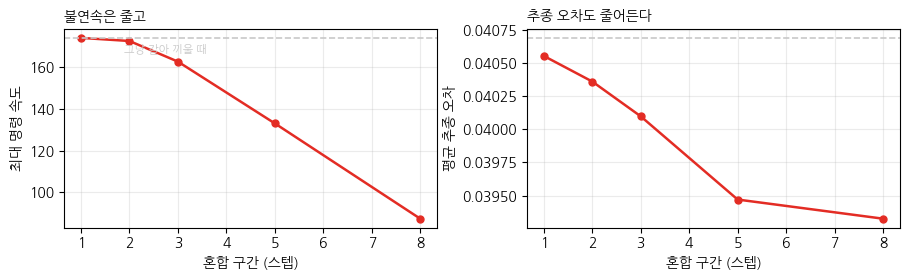

  2              0.04036          172.71


  3              0.04010          162.79


  5              0.03947          133.08


  8              0.03932           87.26


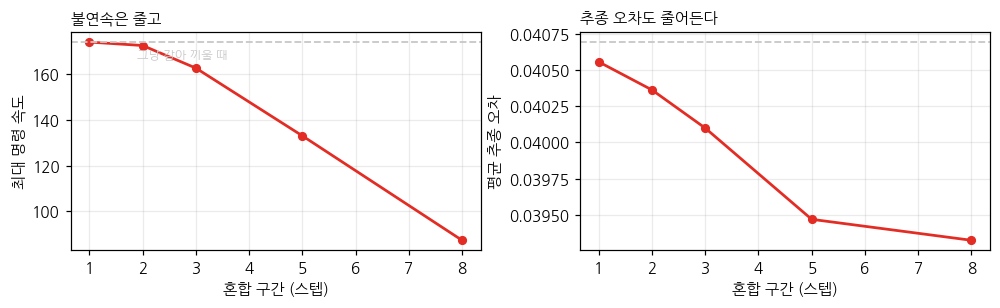

In [3]:
bss = [1, 2, 3, 5, 8]
errs, peaks = [], []
print(f"혼합 구간 길이 (지터 60%)")
print(f"  {'스텝':<8}{'평균 추종오차':>14}{'최대 명령속도':>16}")
print("  " + "-" * 38)
for bs in bss:
    R = np.array([run("blend", .6, s, bs)[:3] for s in range(8)]).mean(0)
    errs.append(R[0]); peaks.append(R[1])
    print(f"  {bs:<8}{R[0]:>14.5f}{R[1]:>16.2f}")

base_err, base_peak = res[("naive", .6)][0], res[("naive", .6)][1]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 2.9))
axes[0].plot(bss, peaks, "o-", color=RED, lw=1.8, ms=5)
axes[0].axhline(base_peak, color=GREY, ls="--", lw=1.2)
axes[0].text(bss[-1]*.45, base_peak*.96, "그냥 갈아 끼울 때", fontsize=8, color=GREY, ha="right")
axes[0].set_xlabel("혼합 구간 (스텝)"); axes[0].set_ylabel("최대 명령 속도")
axes[0].grid(alpha=.25); axes[0].set_title("불연속은 줄고", loc="left", fontsize=10)
axes[1].plot(bss, errs, "o-", color=RED, lw=1.8, ms=5)
axes[1].axhline(base_err, color=GREY, ls="--", lw=1.2)
axes[1].set_xlabel("혼합 구간 (스텝)"); axes[1].set_ylabel("평균 추종 오차")
axes[1].grid(alpha=.25); axes[1].set_title("추종 오차도 줄어든다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 2. 안전 필터 — 배리어로 막는다

15장의 과제를 다시 가져온다. 2차원 도달이고, 장애물에 닿으면 즉시 실패다. 어려운 경우는 장애물이 경로를 정면으로 막는다.

15장에서 본 것: 행동 복제는 어려운 과제에서 16% 에 머물렀고, 시연을 640편까지 늘려도, 개입 데이터를 865쌍 부어도 움직이지 않았다. 8라운드의 RL 사후학습으로 51% 가 됐다.

여기서는 **학습을 전혀 하지 않고** 같은 정책의 출력을 실행 직전에 고친다.

In [4]:
R_OBS = 0.22
def expert_action(p, g, o):
    to = g - p; d = np.linalg.norm(to); u = to / (d + 1e-6)
    v = p - o; dv = np.linalg.norm(v)
    if dv < R_OBS * 1.9:
        n = v / (dv + 1e-6); t = np.array([-n[1], n[0]], np.float32)
        if t @ u < 0: t = -t
        w = np.clip((R_OBS*1.9 - dv) / (R_OBS*0.9), 0, 1)
        u = (1-w)*u + w*(0.75*t + 0.65*n); u = u / (np.linalg.norm(u) + 1e-6)
    return np.clip(u * min(0.12, 0.35*d + 0.04), -0.15, 0.15).astype(np.float32)

def expert_policy(s): return expert_action(s[:2], s[2:4], s[4:6])

def sample_task(rng, p_hard=0.30):
    th = rng.uniform(0, 2*np.pi)
    g = (np.array([np.cos(th), np.sin(th)]) * rng.uniform(.75, .95)).astype(np.float32)
    p = (-g / np.linalg.norm(g) * 0.85).astype(np.float32)
    hard = rng.random() < p_hard; mid = (p + g) / 2
    if hard: o = (mid + rng.normal(0, .14, 2)).astype(np.float32)
    else:
        n = np.array([-(g-p)[1], (g-p)[0]]); n = n / np.linalg.norm(n)
        o = (mid + n * rng.choice([-1, 1]) * rng.uniform(.55, .8)).astype(np.float32)
    return p, g, o.astype(np.float32), hard

def rollout(rng, policy, T=70, p_hard=0.30):
    p, g, o, hard = sample_task(rng, p_hard); S = []; E = []
    for t in range(T):
        s = np.concatenate([p, g, o]).astype(np.float32)
        S.append(s); E.append(expert_action(p, g, o))
        p = np.clip(p + policy(s), -1.05, 1.05)
        if np.linalg.norm(p - o) < R_OBS: return np.array(S), np.array(E), 0, 1, hard
        if np.linalg.norm(p - g) < .10:  return np.array(S), np.array(E), 1, 0, hard
    return np.array(S), np.array(E), 0, 0, hard

class Net(nn.Module):
    def __init__(s, h=128):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(6, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, 2))
    def forward(s, x): return torch.tanh(s.f(x)) * 0.15

def as_policy(m):
    def f(s):
        with torch.no_grad(): return m(torch.tensor(s)[None])[0].numpy()
    return f

def collect(n, seed):
    r = np.random.default_rng(seed); S = []; A = []
    for _ in range(n):
        s, e, *_ = rollout(r, expert_policy); S.append(s); A.append(e)
    return torch.tensor(np.concatenate(S)), torch.tensor(np.concatenate(A))

def fit(X, Y, steps=2000, lr=3e-3, seed=0):
    torch.manual_seed(seed); m = Net()
    opt = torch.optim.AdamW(m.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(4)
    for i in range(steps):
        idx = torch.randint(0, len(X), (256,), generator=g)
        loss = F.smooth_l1_loss(m(X[idx]), Y[idx], beta=.01)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m

def evaluate(policy, n=300, seed=777):
    r = np.random.default_rng(seed); tot = [0, 0]; ok = [0, 0]; cr = 0
    for _ in range(n):
        *_, o, c, hard = rollout(r, policy); i = int(hard); tot[i] += 1; ok[i] += o; cr += c
    return (ok[0]+ok[1])/n, ok[0]/tot[0], ok[1]/tot[1], cr/n

t0 = time.time()
X, Y = collect(160, 0); bc = fit(X, Y)
print(f"BC 학습 {time.time()-t0:.0f}s")

BC 학습 2s


In [5]:
def cbf(p, o, a, alpha=1.0, margin=0.03):
    d = p - o; Rm = R_OBS + margin
    h = float(d @ d - Rm * Rm)          # 안전 여유
    grad = 2 * d                        # dh/dp
    lhs = float(grad @ a)               # 이 액션이 만드는 h 의 변화
    if lhs + alpha * h >= 0:            # 조건을 이미 만족한다
        return a, 0
    lam = -(lhs + alpha * h) / float(grad @ grad + 1e-9)
    return (a + lam * grad).astype(np.float32), 1     # 가장 가까운 안전한 액션

def guarded(model, alpha=1.0, margin=0.03, vmax=0.15, bound=1.05):
    pol = as_policy(model); st = {"n": 0, "k": 0}
    def f(s):
        a = pol(s); st["n"] += 1
        a, k = cbf(s[:2], s[4:6], a, alpha, margin); st["k"] += k
        a = np.clip(a, -vmax, vmax)                       # 속도 제한
        return (np.clip(s[:2] + a, -bound, bound) - s[:2]).astype(np.float32)   # 워크스페이스 바운드
    return f, st

print(f"{'구성':<26}{'전체':>8}{'쉬움':>8}{'어려움':>9}{'충돌':>8}{'필터 개입':>10}")
print("-" * 69)
e = evaluate(expert_policy)
print(f"{'전문가':<26}{e[0]:>7.0%}{e[1]:>8.0%}{e[2]:>9.0%}{e[3]:>8.0%}{'-':>10}")
s0 = evaluate(as_policy(bc))
print(f"{'BC (필터 없음)':<26}{s0[0]:>7.0%}{s0[1]:>8.0%}{s0[2]:>9.0%}{s0[3]:>8.0%}{'-':>10}")
f, st = guarded(bc)
s1 = evaluate(f)
print(f"{'BC + 안전 필터':<26}{s1[0]:>7.0%}{s1[1]:>8.0%}{s1[2]:>9.0%}{s1[3]:>8.0%}{st['k']/max(st['n'],1):>10.0%}")

p_ = np.array([.1, .2], np.float32); o_ = np.array([0., 0.], np.float32); a_ = np.array([.1, 0.], np.float32)
t0 = time.perf_counter()
for _ in range(20000): cbf(p_, o_, a_)
print(f"\n필터 한 번의 비용: {(time.perf_counter()-t0)/20000*1000:.4f} ms")

구성                              전체      쉬움      어려움      충돌     필터 개입
---------------------------------------------------------------------
전문가                          100%    100%     100%      0%         -
BC (필터 없음)                    75%    100%      16%     25%         -
BC + 안전 필터                    96%    100%      88%      0%       10%

필터 한 번의 비용: 0.0013 ms


BC (필터 없음)                    75%    100%      16%     25%         -


BC + 안전 필터                    96%    100%      88%      0%       10%

필터 한 번의 비용: 0.0041 ms


## 3. 필터의 조건과 한계

필터에는 손잡이가 둘 있다. $\alpha$ 는 얼마나 늦게까지 버티다 개입할지를, 여유(margin)는 장애물을 얼마나 크게 볼지를 정한다.

구성                              전체      쉬움      어려움      충돌      개입
-------------------------------------------------------------------
α=0.5, 여유=0.03                95%    100%      83%      0%     14%
α=1.0, 여유=0.03                96%    100%      88%      0%     10%
α=2.0, 여유=0.03                88%    100%      59%     10%      5%
α=4.0, 여유=0.03                81%    100%      37%     18%      2%
α=1.0, 여유=0.08                92%    100%      72%      0%     11%
α=1.0, 여유=0.15                87%    100%      58%      0%     13%


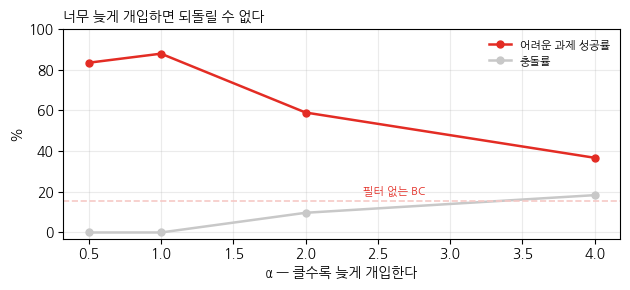

α=1.0, 여유=0.03                96%    100%      88%      0%     10%


α=2.0, 여유=0.03                88%    100%      59%     10%      5%


α=4.0, 여유=0.03                81%    100%      37%     18%      2%


α=1.0, 여유=0.08                92%    100%      72%      0%     11%


α=1.0, 여유=0.15                87%    100%      58%      0%     13%


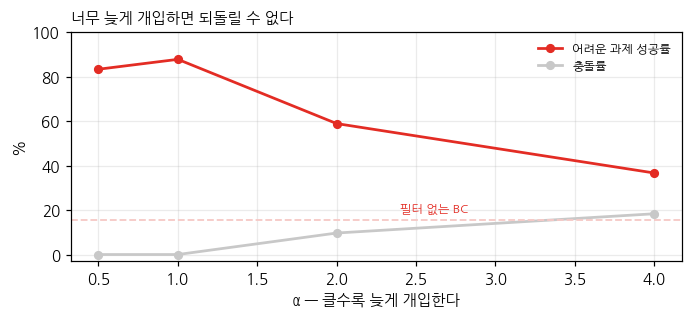

In [6]:
print(f"{'구성':<26}{'전체':>8}{'쉬움':>8}{'어려움':>9}{'충돌':>8}{'개입':>8}")
print("-" * 67)
rows = []
for al, mg in [(0.5, .03), (1.0, .03), (2.0, .03), (4.0, .03), (1.0, .08), (1.0, .15)]:
    f, st = guarded(bc, alpha=al, margin=mg)
    s = evaluate(f); rows.append((al, mg, s, st["k"]/max(st["n"], 1)))
    print(f"{f'α={al}, 여유={mg}':<26}{s[0]:>7.0%}{s[1]:>8.0%}{s[2]:>9.0%}{s[3]:>8.0%}{st['k']/max(st['n'],1):>8.0%}")

fig, ax = plt.subplots(figsize=(6.4, 3.0))
al_rows = [r for r in rows if r[1] == .03]
ax.plot([r[0] for r in al_rows], [r[2][2]*100 for r in al_rows], "o-", color=RED, lw=1.8, ms=5, label="어려운 과제 성공률")
ax.plot([r[0] for r in al_rows], [r[2][3]*100 for r in al_rows], "o-", color=GREY, lw=1.8, ms=5, label="충돌률")
ax.axhline(s0[2]*100, color=PINK, ls="--", lw=1.2)
ax.text(al_rows[-1][0]*.6, s0[2]*100+3, "필터 없는 BC", fontsize=8, color=RED)
ax.set_xlabel("α — 클수록 늦게 개입한다"); ax.set_ylabel("%")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25); ax.set_ylim(-3, 100)
ax.set_title("너무 늦게 개입하면 되돌릴 수 없다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 실패를 미리 알아채기

막을 수 있는 실패는 막았다. 남은 것은 **막을 수 없는 실패를 알아채는 것**이다. 정책이 헤매고 있다는 신호를 실패 전에 얻을 수 있으면 사람에게 넘기거나 안전하게 멈출 수 있다.

라벨이 필요 없는 신호를 쓴다. **같은 데이터로 학습한 여러 정책이 서로 얼마나 다른 말을 하는가** — 인식적 불확실성이다.

앙상블 4개 학습 4s

실패 예측 AUC  (n=220, 실패 53편, 기저 실패율 24%)
  에피소드 평균 불일치                   0.827
  첫 5스텝 평균 불일치 (사전 경고)          0.770

첫 5스텝 신호로 사람에게 넘길 때
  넘기는 비율               넘긴 것 중 실패       놓친 실패
  --------------------------------------------
  10%                       68%         72%
  20%                       59%         51%
  30%                       47%         42%
  50%                       37%         23%


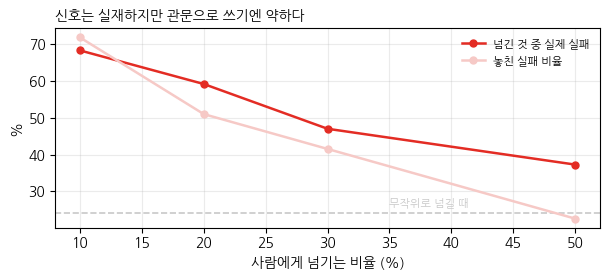

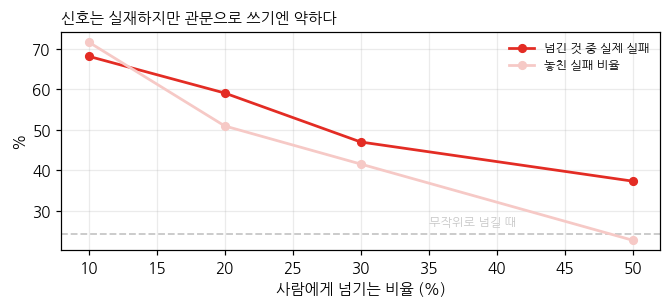

In [7]:
t0 = time.time()
ENS = 4
ens = [fit(X, Y, seed=s_) for s_ in range(ENS)]
main = ens[0]
print(f"앙상블 {ENS}개 학습 {time.time()-t0:.0f}s")

def disagree(s):
    with torch.no_grad():
        A = np.stack([m(torch.tensor(s)[None])[0].numpy() for m in ens])
    return float(np.linalg.norm(A - A.mean(0), axis=1).mean())

def roll_signal(rng, policy):
    p, g, o, hard = sample_task(rng, .30); D = []
    for t in range(70):
        s = np.concatenate([p, g, o]).astype(np.float32)
        D.append(disagree(s)); p = np.clip(p + policy(s), -1.05, 1.05)
        if np.linalg.norm(p - o) < R_OBS: return np.array(D), 0, hard
        if np.linalg.norm(p - g) < .10:  return np.array(D), 1, hard
    return np.array(D), 0, hard

pol = as_policy(main); rng = np.random.default_rng(31); rows = []
for _ in range(220):
    D, ok, hard = roll_signal(rng, pol)
    rows.append((D.mean(), D[:5].mean(), ok, hard))
A = np.array(rows); fail = 1 - A[:, 2]

def auc(score, label):
    o = np.argsort(score); l = label[o]; P = l.sum(); N = len(l) - P
    r = np.arange(1, len(l) + 1)
    return (r[l == 1].sum() - P*(P+1)/2) / (P*N)

print(f"\n실패 예측 AUC  (n={len(A)}, 실패 {int(fail.sum())}편, 기저 실패율 {fail.mean():.0%})")
print(f"  {'에피소드 평균 불일치':<30}{auc(A[:,0], fail):.3f}")
print(f"  {'첫 5스텝 평균 불일치 (사전 경고)':<30}{auc(A[:,1], fail):.3f}")

sc = A[:, 1]
print(f"\n첫 5스텝 신호로 사람에게 넘길 때")
print(f"  {'넘기는 비율':<14}{'넘긴 것 중 실패':>16}{'놓친 실패':>12}")
print("  " + "-" * 44)
hand, prec, miss = [], [], []
for q in (.9, .8, .7, .5):
    th = np.quantile(sc, q); sel = sc >= th
    hand.append(sel.mean()*100); prec.append(fail[sel].mean()*100)
    miss.append(fail[~sel].sum()/max(fail.sum(),1)*100)
    print(f"  {sel.mean():<14.0%}{fail[sel].mean():>15.0%}{fail[~sel].sum()/max(fail.sum(),1):>12.0%}")

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.plot(hand, prec, "o-", color=RED, lw=1.8, ms=5, label="넘긴 것 중 실제 실패")
ax.axhline(fail.mean()*100, color=GREY, ls="--", lw=1.2)
ax.text(hand[-1]*.7, fail.mean()*100+2, "무작위로 넘길 때", fontsize=8, color=GREY)
ax.plot(hand, miss, "o-", color=PINK, lw=1.8, ms=5, label="놓친 실패 비율")
ax.set_xlabel("사람에게 넘기는 비율 (%)"); ax.set_ylabel("%")
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=.25)
ax.set_title("신호는 실재하지만 관문으로 쓰기엔 약하다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로
마지막 장에서는 시야를 한 단계 넓힌다. 이 모든 것을 굴리려면 어떤 인프라가 필요한지, 그리고 2026년 현재 이 분야가 **아직 풀지 못한 문제**가 무엇인지를 본다.